In [1]:
import uproot
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from rich.progress import Progress
import ast
import json
import pyvista as pv
import pandas as pd
from scipy.spatial.transform import Rotation

In [2]:
# Read the DetectorSinglesBlurActor tree from the first root file and convert to a polars DataFrame
pl_df_list = []
root_file_list = sorted(Path("../").glob("pixel_singles_*.root"))
first_n = 10
n_heads = 80
with Progress() as progress:
    progrees_task = progress.add_task("Processing root files...", total=first_n)
    for root_fpath in root_file_list[:first_n]:
        runfile_id = int(root_fpath.name.split("_")[-1].split(".")[0])
        with uproot.open(root_fpath) as f:
            for i in range(n_heads):
                tree = f[f"Pixel_{i + 1}_Singles"]
                tree_np = tree.arrays(library="np")
                pl_df = pl.DataFrame(tree_np).select(
                    pl.lit(i + 1).alias("HeadID"),
                    pl.all(),
                )
                pl_df_list.append(pl_df)
        progress.update(progrees_task, advance=1)
    # Concatenate all DataFrames in the list into a single DataFrame
    pl_df = pl.concat(pl_df_list, how="vertical")
# remove the list to free up memory
del pl_df_list

Output()

In [3]:
print(pl_df.head())


shape: (5, 20)
┌────────┬───────┬──────────┬─────────┬───┬──────────────┬─────────────┬─────────────┬─────────────┐
│ HeadID ┆ RunID ┆ ThreadID ┆ EventID ┆ … ┆ PreStepUniqu ┆ PreStepUniq ┆ PostStepUni ┆ TrackVolume │
│ ---    ┆ ---   ┆ ---      ┆ ---     ┆   ┆ eVolumeID    ┆ ueVolumeIDA ┆ queVolumeID ┆ Name        │
│ i32    ┆ i32   ┆ i32      ┆ i32     ┆   ┆ ---          ┆ sInt        ┆ AsInt       ┆ ---         │
│        ┆       ┆          ┆         ┆   ┆ str          ┆ ---         ┆ ---         ┆ str         │
│        ┆       ┆          ┆         ┆   ┆              ┆ i32         ┆ i32         ┆             │
╞════════╪═══════╪══════════╪═════════╪═══╪══════════════╪═════════════╪═════════════╪═════════════╡
│ 1      ┆ 0     ┆ -1       ┆ 29151   ┆ … ┆ pixel_1_para ┆ 1           ┆ 1           ┆ pixel_1_par │
│        ┆       ┆          ┆         ┆   ┆ m-0_0_299    ┆             ┆             ┆ am          │
│ 1      ┆ 0     ┆ -1       ┆ 475080  ┆ … ┆ pixel_1_para ┆ 1           ┆ 1  

In [4]:
# Print Unique HeadIDs
print(pl_df.select(pl.col("HeadID").unique()))
# Print Unique EventIDs
print(pl_df.select(pl.col("EventID").unique()))

shape: (80, 1)
┌────────┐
│ HeadID │
│ ---    │
│ i32    │
╞════════╡
│ 1      │
│ 2      │
│ 3      │
│ 4      │
│ 5      │
│ …      │
│ 76     │
│ 77     │
│ 78     │
│ 79     │
│ 80     │
└────────┘
shape: (601, 1)
┌─────────┐
│ EventID │
│ ---     │
│ i32     │
╞═════════╡
│ 1917    │
│ 2701    │
│ 5341    │
│ 6179    │
│ 6959    │
│ …       │
│ 988566  │
│ 991522  │
│ 992090  │
│ 994373  │
│ 1000851 │
└─────────┘


In [6]:
print(f"{(len(pl_df.select(pl.col("EventID").unique()))/1e6):.5%} of the events have energy deposition in the pixel detector.")

0.06010% of the events have energy deposition in the pixel detector.


In [7]:
print(pl_df.columns)

['HeadID', 'RunID', 'ThreadID', 'EventID', 'TrackID', 'TotalEnergyDeposit', 'PostPosition_X', 'PostPosition_Y', 'PostPosition_Z', 'PrePosition_X', 'PrePosition_Y', 'PrePosition_Z', 'EventPosition_X', 'EventPosition_Y', 'EventPosition_Z', 'GlobalTime', 'PreStepUniqueVolumeID', 'PreStepUniqueVolumeIDAsInt', 'PostStepUniqueVolumeIDAsInt', 'TrackVolumeName']


In [3]:
# Get Unique PostStepUniqueVolumeID for each head
n_unique_ID = []
for head_id in range(1, n_heads + 1):
    unique_volumes = pl_df.filter(pl.col("HeadID") == head_id).select(
        pl.col("PreStepUniqueVolumeID").unique()
    )
    n_unique_ID.append(len(unique_volumes))
    # print(f"Head {head_id} has {len(unique_volumes)} unique PreStepUniqueVolumeID.")
# Print Unique PostStepUniqueVolumeIDAsInt for the head with the most unique PreStepUniqueVolumeID
max_unique_ID_head = np.argmax(n_unique_ID) + 1
print(f"Head {max_unique_ID_head} has the most unique PreStepUniqueVolumeID: {n_unique_ID[max_unique_ID_head - 1]}")
print(pl_df.filter(pl.col("HeadID") == max_unique_ID_head).select(pl.col("PreStepUniqueVolumeID")).unique())
# Strip the last field with separator "_" to get the pixel ID
pl_df = pl_df.with_columns(
    pl.col("PreStepUniqueVolumeID")
    .str.split("_")
    .list.last()
    .cast(pl.Int32)
    .alias("PixelID")
)
# Move the PixelID column to second column, but keep only columns that exist
desired_columns = [
    "HeadID",
    "PixelID",
    "EventID",
    "TrackID",
    "PreStepUniqueVolumeID",
    "PostStepUniqueVolumeIDAsInt",
    "PreStepKineticEnergy",
    "PostStepKineticEnergy",
    "PreStepGlobalTime",
    "PostStepGlobalTime",
    "PrePosition_X",
    "PrePosition_Y",
    "PrePosition_Z",
    "PostPosition_X",
    "PostPosition_Y",
    "PostPosition_Z",
]
pl_df = pl_df.select([pl.col(col) for col in desired_columns if col in pl_df.columns])

Head 47 has the most unique PreStepUniqueVolumeID: 145
shape: (145, 1)
┌────────────────────────┐
│ PreStepUniqueVolumeID  │
│ ---                    │
│ str                    │
╞════════════════════════╡
│ pixel_47_param-0_0_169 │
│ pixel_47_param-0_0_21  │
│ pixel_47_param-0_0_243 │
│ pixel_47_param-0_0_325 │
│ pixel_47_param-0_0_2   │
│ …                      │
│ pixel_47_param-0_0_581 │
│ pixel_47_param-0_0_419 │
│ pixel_47_param-0_0_105 │
│ pixel_47_param-0_0_84  │
│ pixel_47_param-0_0_350 │
└────────────────────────┘


In [20]:
print(pl_df.head())
# Find the range of PixelID for each head
pixel_id_range = pl_df.group_by("HeadID").agg(
    pl.col("PixelID").min().alias("PixelID_min"),
    pl.col("PixelID").max().alias("PixelID_max"),
)
print(pixel_id_range)

shape: (5, 12)
┌────────┬─────────┬─────────┬─────────┬───┬─────────────┬─────────────┬─────────────┬─────────────┐
│ HeadID ┆ PixelID ┆ EventID ┆ TrackID ┆ … ┆ PrePosition ┆ PostPositio ┆ PostPositio ┆ PostPositio │
│ ---    ┆ ---     ┆ ---     ┆ ---     ┆   ┆ _Z          ┆ n_X         ┆ n_Y         ┆ n_Z         │
│ i32    ┆ i32     ┆ i32     ┆ i32     ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│        ┆         ┆         ┆         ┆   ┆ f64         ┆ f64         ┆ f64         ┆ f64         │
╞════════╪═════════╪═════════╪═════════╪═══╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 1      ┆ 299     ┆ 29151   ┆ 1       ┆ … ┆ -114.057462 ┆ 360.512003  ┆ 89.523089   ┆ -115.736297 │
│ 1      ┆ 443     ┆ 475080  ┆ 1       ┆ … ┆ -102.279547 ┆ 360.325502  ┆ 101.856891  ┆ -104.081146 │
│ 2      ┆ 332     ┆ 498370  ┆ 1       ┆ … ┆ -82.325279  ┆ 321.971836  ┆ 144.373908  ┆ -83.02818   │
│ 3      ┆ 39      ┆ 342996  ┆ 1       ┆ … ┆ -96.795664  ┆ 276.941923  ┆ 161

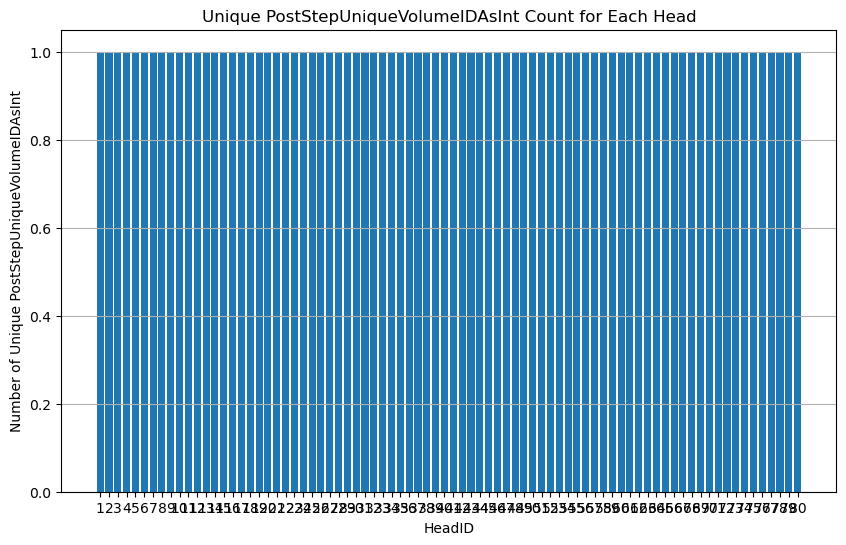

In [33]:
# Get Unique PostStepUniqueVolumeIDAsInt for each head
unique_volIDAsInt = []
for head_id in range(1, n_heads + 1):
    unique_volumes = pl_df.filter(pl.col("HeadID") == head_id).select(
        pl.col("PostStepUniqueVolumeIDAsInt").unique()
    )
    unique_volIDAsInt.append(len(unique_volumes))
# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, n_heads + 1), unique_volIDAsInt)
ax.set_xlabel("HeadID")
ax.set_ylabel("Number of Unique PostStepUniqueVolumeIDAsInt")
ax.set_title("Unique PostStepUniqueVolumeIDAsInt Count for Each Head")
plt.xticks(range(1, n_heads + 1))
plt.grid(axis="y")
plt.show()



In [20]:
def get_dc_spect_geometry_config(xlsx_path: Path):

    n_heads = 80
    collimator_hole_size_mm = 2.3  # unit is mm
    collimator_wall_thickness_mm = 2.0  # unit is mm
    collimator_guide_length_mm = 3.0
    detector_crystal_size_mm = [50.0, 50.0, 10.0]  # unit is mm

    df_coords = pd.read_excel(
        xlsx_path, sheet_name="Coordinates"
    )  # read the "Coordinates" sheet
    df_coords.columns = df_coords.iloc[0]
    df_coords = df_coords[1:]  # remove the first row which is now the header
    df_coords = df_coords.reset_index(
        drop=True
    )  # reset the index after removing the first row
    df_coords = df_coords.apply(
        pd.to_numeric, errors="coerce"
    )  # convert all columns to numeric, coercing errors to NaN
    df_coords.columns.name = "Coordinates Sheet"

    collimator_body_length_mm_np = df_coords["length of collimator"].values
    collimator_hole_coords_mm = df_coords[
        [
            "x coordinate value at center of hole",
            "y coordinate value at center of hole",
            "z coordinate value at center of hole",
        ]
    ].values

    # Fail early if the spreadsheet contains non-numeric values in required fields.
    if (
        np.isnan(collimator_body_length_mm_np).any()
        or np.isnan(collimator_hole_coords_mm).any()
    ):
        raise ValueError(
            "Invalid geometry spreadsheet values detected (NaN) in required columns. "
            "Please check the Coordinates sheet numeric fields."
        )

    if not isinstance(collimator_body_length_mm_np, np.ndarray):
        collimator_body_length_mm_np = np.asarray(collimator_body_length_mm_np)

    if not isinstance(collimator_hole_coords_mm, np.ndarray):
        collimator_hole_coords_mm_np = np.asarray(collimator_hole_coords_mm)
    else:
        collimator_hole_coords_mm_np = collimator_hole_coords_mm

    hole_fov_center_distance_mm_np = np.linalg.norm(
        collimator_hole_coords_mm_np, axis=1
    )
    azmuthal_angle_deg = (
        np.arctan2(
            collimator_hole_coords_mm_np[:, 1], collimator_hole_coords_mm_np[:, 0]
        )
        * 180
        / np.pi
    )
    hole_fov_center_dist_xy_mm_np = np.linalg.norm(
        collimator_hole_coords_mm_np[:, :2], axis=1
    )
    polar_angle_deg = (
        np.arctan2(collimator_hole_coords_mm_np[:, 2], hole_fov_center_dist_xy_mm_np)
        * 180
        / np.pi
    )
    collimator_body_center_dist_mm_np = (
        hole_fov_center_distance_mm_np + collimator_body_length_mm_np * 0.5
    )
    collimator_body_translation_mm = collimator_body_center_dist_mm_np.reshape(
        -1, 1
    ) * np.column_stack(
        (
            np.cos(np.radians(polar_angle_deg))
            * np.cos(np.radians(azmuthal_angle_deg)),
            np.cos(np.radians(polar_angle_deg))
            * np.sin(np.radians(azmuthal_angle_deg)),
            np.sin(np.radians(polar_angle_deg)),
        )
    )
    detector_crystal_center_dist_mm_np = (
        hole_fov_center_distance_mm_np
        + collimator_body_length_mm_np
        + detector_crystal_size_mm[2] * 0.5
    )
    detector_crystal_translation_mm = detector_crystal_center_dist_mm_np.reshape(
        -1, 1
    ) * np.column_stack(
        (
            np.cos(np.radians(polar_angle_deg))
            * np.cos(np.radians(azmuthal_angle_deg)),
            np.cos(np.radians(polar_angle_deg))
            * np.sin(np.radians(azmuthal_angle_deg)),
            np.sin(np.radians(polar_angle_deg)),
        )
    )

    collimator_wall_thickness_mm_np = np.full((n_heads,), collimator_wall_thickness_mm)
    collimator_body_inner_top_mm_np = np.full((n_heads,), detector_crystal_size_mm[0])
    collimator_body_inner_bottom_mm_np = np.full((n_heads,), collimator_hole_size_mm)
    collimator_body_outer_top_mm_np = (
        collimator_body_inner_top_mm_np + collimator_wall_thickness_mm_np * 2
    )
    collimator_body_outer_bottom_mm_np = (
        collimator_body_inner_bottom_mm_np + collimator_wall_thickness_mm_np * 2
    )

    collimator_guide_exit_angle_rad = np.arctan2(
        (collimator_body_inner_top_mm_np + collimator_body_inner_bottom_mm_np) * 0.5,
        collimator_body_length_mm_np,
    )

    collimator_guide_length_mm_np = np.full((n_heads,), collimator_guide_length_mm)
    collimator_guide_distance_mm_np = (
        hole_fov_center_distance_mm_np - collimator_guide_length_mm_np
    )
    collimator_guide_translation_mm = collimator_guide_distance_mm_np.reshape(
        -1, 1
    ) * np.column_stack(
        (
            np.cos(np.radians(polar_angle_deg))
            * np.cos(np.radians(azmuthal_angle_deg)),
            np.cos(np.radians(polar_angle_deg))
            * np.sin(np.radians(azmuthal_angle_deg)),
            np.sin(np.radians(polar_angle_deg)),
        )
    )

    collimator_guide_inner_top_mm_np = np.full((n_heads,), collimator_hole_size_mm)
    collimator_guide_outer_top_mm_np = (
        collimator_guide_inner_top_mm_np + collimator_wall_thickness_mm_np * 2
    )
    collimator_guide_inner_bottom_mm_np = (
        collimator_guide_inner_top_mm_np
        + np.tan(collimator_guide_exit_angle_rad) * collimator_guide_length_mm_np * 2
    )
    collimator_guide_outer_bottom_mm_np = (
        collimator_guide_inner_bottom_mm_np + collimator_wall_thickness_mm_np * 2
    )

    return {
        "collimator_body_length_mm_np": collimator_body_length_mm_np,
        "collimator_hole_coords_mm_np": collimator_hole_coords_mm_np,
        "collimator_body_translation_mm": collimator_body_translation_mm,
        "collimator_body_inner_top_mm_np": collimator_body_inner_top_mm_np,
        "collimator_body_inner_bottom_mm_np": collimator_body_inner_bottom_mm_np,
        "collimator_body_outer_top_mm_np": collimator_body_outer_top_mm_np,
        "collimator_body_outer_bottom_mm_np": collimator_body_outer_bottom_mm_np,
        "collimator_guide_length_mm_np": collimator_guide_length_mm_np,
        "collimator_guide_translation_mm": collimator_guide_translation_mm,
        "collimator_guide_inner_top_mm_np": collimator_guide_inner_top_mm_np,
        "collimator_guide_outer_top_mm_np": collimator_guide_outer_top_mm_np,
        "collimator_guide_inner_bottom_mm_np": collimator_guide_inner_bottom_mm_np,
        "collimator_guide_outer_bottom_mm_np": collimator_guide_outer_bottom_mm_np,
        "detector_crystal_size_mm": detector_crystal_size_mm,
        "detector_crystal_translation_mm": detector_crystal_translation_mm,
        "azmuthal_angle_deg": azmuthal_angle_deg,
        "polar_angle_deg": polar_angle_deg,
    }




dc_spect_config = get_dc_spect_geometry_config(
    Path("/home/fanghan/Work/RPIL/QMIRT/gate10mc/persistent_data/")
    / "spreadsheet/MDSL.excel80M10RFR.cut-plate.010.150roi.2.30pin.105ellipse.xlsx"
)

azmuthal_angle_deg_raw = dc_spect_config["azmuthal_angle_deg"]
polar_angle_deg_raw = dc_spect_config["polar_angle_deg"]
monolithic_crystal_translation_raw = dc_spect_config["detector_crystal_translation_mm"]

n_pixels = np.array([1, 1, 1])
monolithic_crystal_size = np.array([50.0, 50.0, 10.0])

sampling_interval = 1
azmuthal_angle_deg = azmuthal_angle_deg_raw[::sampling_interval]
polar_angle_deg = polar_angle_deg_raw[::sampling_interval]
monolithic_crystal_translation = monolithic_crystal_translation_raw[::sampling_interval]


pixel_box_size = monolithic_crystal_size / n_pixels

# Generate a grid of 3D Boxes with center at the origin
def generate_grid_points(grid: np.ndarray, spacing: np.ndarray) -> np.ndarray:
    x_grid, y_grid, z_grid = [
        np.arange(n) * s - (n-1)*s * 0.5
        for n, s, in zip(grid, spacing)
    ]
    return np.stack(np.meshgrid(x_grid, y_grid, z_grid, indexing='xy'), axis=-1)

local_array_translations = generate_grid_points(
    n_pixels, pixel_box_size
).reshape(-1, 3)
print(f"Local array translations shape: {local_array_translations.shape}")
def generate_box_at_points(points: np.ndarray, box_size: np.ndarray) -> np.ndarray:
    # Create a box centered at the origin
    half_size = box_size / 2
    box_corners = np.array([
        [-half_size[0], -half_size[1], -half_size[2]],
        [ half_size[0], -half_size[1], -half_size[2]],
        [ half_size[0],  half_size[1], -half_size[2]],
        [-half_size[0],  half_size[1], -half_size[2]],
        [-half_size[0], -half_size[1],  half_size[2]],
        [ half_size[0], -half_size[1],  half_size[2]],
        [ half_size[0],  half_size[1],  half_size[2]],
        [-half_size[0],  half_size[1],  half_size[2]],
    ])
    
    # Translate the box to each point in the grid
    boxes_vertices = points[:, None,:] + box_corners

    # Get boxes edges
    return boxes_vertices
    
global_pixel_translations = []
global_pixel_rotations = []
for i in range(monolithic_crystal_translation.shape[0]):
    # First rotate around x axis by 90 degrees
    rx_0 = Rotation.from_euler("x", -90, degrees=True).as_matrix()
    rz_0 = Rotation.from_euler("z", 90, degrees=True).as_matrix()
    # Then rotate around z axis by the azmuthal angle
    rz_1 = Rotation.from_euler("z", azmuthal_angle_deg[i], degrees=True).as_matrix()

    # # Then rotate around y axis by the polar angle
    rx_1 = Rotation.from_euler("x", -polar_angle_deg[i], degrees=True).as_matrix()
    r = rz_1 @ rz_0 @ rx_1 @ rx_0
    # r = rz_1 @ rz_0
    global_pixel_translations.extend(
        [
            Rotation.from_matrix(r).apply(local_translation) + monolithic_crystal_translation[i]
            for local_translation in local_array_translations
        ]
    )


    global_pixel_rotations.extend([r]*n_pixels.prod())


print(f"Global pixel translations shape: {np.array(global_pixel_translations).shape}")
print(f"Global pixel rotations shape: {np.array(global_pixel_rotations).shape}")

# Create an array of (0,0,0)
zero_list = [np.array([[0, 0, 0]])] * len(global_pixel_translations)
boxes = generate_box_at_points(np.array(zero_list), pixel_box_size)
for i in range(len(boxes)):
    boxes[i] = Rotation.from_matrix(global_pixel_rotations[i]).apply(boxes[i])
print(f"Boxes shape before translation: {boxes.shape}")
# boxes= np.array(boxes).reshape(-1, 8, 3) + np.array(global_pixel_translations).reshape(boxes.shape)

Local array translations shape: (1, 3)
Global pixel translations shape: (80, 3)
Global pixel rotations shape: (80, 3, 3)
Boxes shape before translation: (80, 1, 8, 3)


In [21]:
vertices = []
box_intrinsic_quad_faces = np.array(
    [
        [4,0, 1, 2, 3],  # Bottom face
        [4,4, 5, 6, 7],  # Top face
        [4,0, 1, 5, 4],  # Front face
        [4,2, 3, 7, 6],  # Back face
        [4,0, 3, 7, 4],  # Left face
        [4,1, 2, 6, 5],  # Right face
    ]
)
faces = []
for i, box in enumerate(boxes):
    vertices.extend(box)
    faces.extend(box_intrinsic_quad_faces + np.stack([0, 8, 8, 8, 8]) * i)

print(f"Vertices shape: {np.array(vertices).shape}")
print(f"Faces shape: {np.array(faces).shape}")

detector_pixels_mesh = pv.PolyData(np.array(vertices).reshape(-1, 3), np.array(faces))

Vertices shape: (80, 8, 3)
Faces shape: (480, 5)


In [22]:
# Get Singles Postion, filter out event with trackID = 0
position = pl_df.filter(pl.col("TrackID") != 0).select(
    pl.col("PostPosition_X"),
    pl.col("PostPosition_Y"),
    pl.col("PostPosition_Z")
    ).to_numpy()
print(position.shape)
# local_position = pl_df.filter(pl.col("TrackID") != 0).select(
#     pl.col("PostLocalPosition_X"),
#     pl.col("PostLocalPosition_Y"),
#     pl.col("PostLocalPosition_Z")
#     ).to_numpy()
# print(local_position.shape)

(6510, 3)


In [24]:
# Plot the position of the singles with pvista
collimator_mesh = pv.read("/home/fanghan/Work/RPIL/QMIRT/gate10mc/persistent_data/stl/MDSL_cloud.009.tungsten.STL")
# 2. 开启无屏渲染模式 (针对远程服务器)
plotter = pv.Plotter()
collimator_mesh.rotate_x(90,inplace=True)  # STL 模型通常需要旋转才能正确显示
shielding_mesh = pv.read("/home/fanghan/Work/RPIL/QMIRT/gate10mc/persistent_data/stl/dc_spect_shielding_combined.stl")
shielding_mesh.rotate_z(90,inplace=True)
plotter.add_mesh(
    collimator_mesh, 
    color='lightblue',       # 设置模型颜色
    show_edges=False,        # 不显示密集的三角形边框
    smooth_shading=False,     # 开启平滑光照
    specular=0.5             # 增加一点高光让模型更有质感
)
plotter.add_mesh(shielding_mesh, color='gray')
# plotter.add_mesh(detector_pixels_mesh, show_edges=True, color='cyan', opacity=0.8,line_width=0.5)


# Add 3d scatter plot of the postion of the singles
plotter.add_points(position, color='red', point_size=5, render_points_as_spheres=True)



plotter.export_html("my_stl_render.html")

plotter.close()



No matching fbConfigs or visuals found
glx: failed to create drisw screen
No matching fbConfigs or visuals found
glx: failed to create drisw screen
2026-05-13 10:54:10.583 ( 775.458s) [    79532B19E740]vtkXOpenGLRenderWindow.:732   WARN| vtkXOpenGLRenderWindow (0x58fc65002010): Cannot create GLX context.
2026-05-13 10:54:10.583 ( 775.458s) [    79532B19E740]vtkOpenGLRenderWindow.c:919   WARN| vtkXOpenGLRenderWindow (0x58fc65002010): Failed to initialize OpenGL functions!
